<a href="https://colab.research.google.com/github/saifullah-ai-engineer/AI-Deep-Learning/blob/NLP/Embedding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

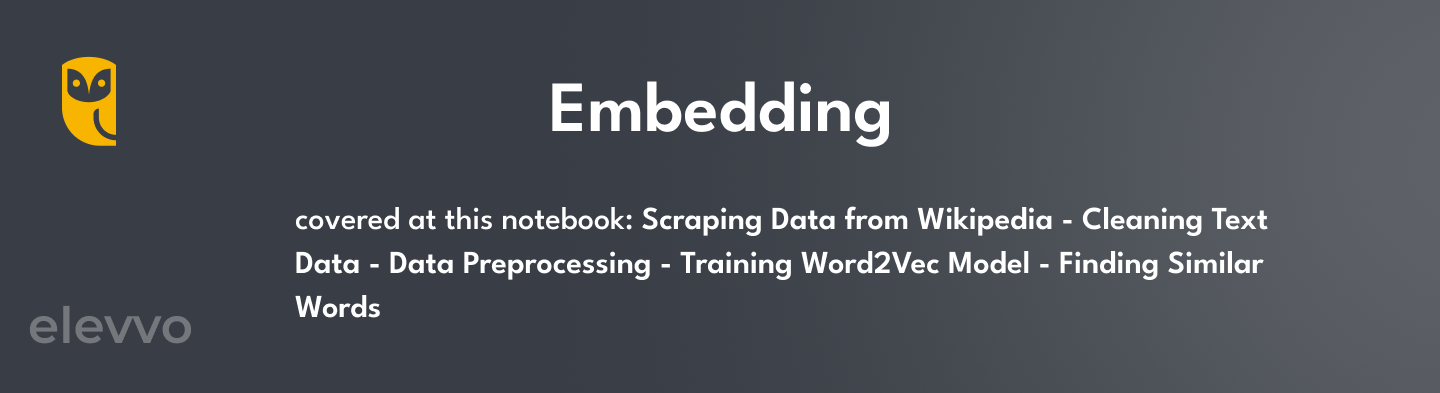

```
📌 An embedding is a numerical representation of a piece of
 information, for example, text, documents, images, audio,
 etc. The representation captures the semantic meaning of what
  is being embedded, making it robust for many industry applications.
```

# Word2Vec using Gensim

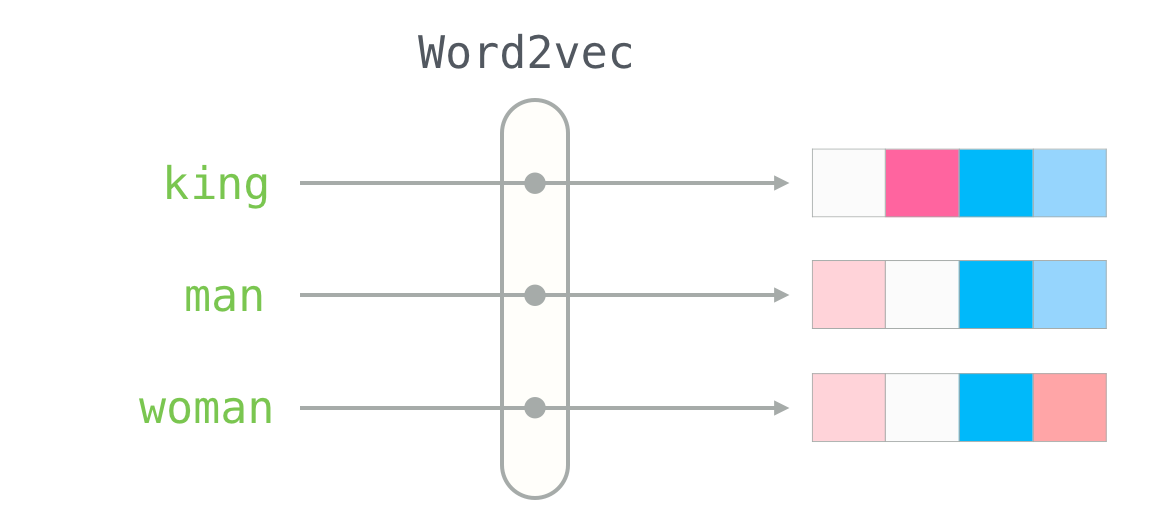

📌 ` First, we will retrieves the content of a Wikipedia page, `isolates the paragraphs, and combines them into a single piece of text for further processing.

📌 `bs4:` Beautiful Soup is used to extract data from HTML and XML files, like the Wikipedia page.

In [6]:
import bs4 as bs
import urllib.request
import re
import nltk


scrapped_data = urllib.request.urlopen("https://www.ibm.com/think/topics/artificial-intelligence")
article = scrapped_data .read()

parsed_article = bs.BeautifulSoup(article,'lxml')

paragraphs = parsed_article.find_all('p')

article_text = ""

for p in paragraphs:
    article_text += p.text
article_text

'Editorial Lead, AI ModelsProgram ManagerArtificial intelligence (AI) is technology that enables computers and machines to simulate human learning, comprehension, problem solving, decision making, creativity and autonomy.Applications and devices equipped with AI can see and identify objects. They can understand and respond to human language. They can learn from new information and experience. They can make detailed recommendations to users and experts.\xa0They can act independently, replacing the need for human intelligence or intervention (a classic example being a self-driving car).But in 2024, most AI researchers, practitioners and most AI-related headlines are focused on breakthroughs in generative AI\xa0(gen AI), a technology that can create original text, images, video and other content. To fully understand generative AI, it’s important to first understand the technologies on which generative AI tools are built: machine learning\xa0(ML) and deep learning.\nThink NewsletterJoin ov

`📌 Preprocessing steps ( check part 1: Text Preprocessing if not familiar )`

In [7]:
import nltk
from nltk.corpus import stopwords
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [8]:
# Cleaning the text
processed_article = article_text.lower()
processed_article = re.sub('[^a-zA-Z]', ' ', processed_article )
processed_article = re.sub(r'\s+', ' ', processed_article)

# Preparing the dataset
all_words = nltk.word_tokenize(processed_article)
all_words

#Removing Stop Words
stop_words = set(stopwords.words('english'))
cleaned_text = [word for word in all_words if word not in stop_words]

cleaned_text

['editorial',
 'lead',
 'ai',
 'modelsprogram',
 'managerartificial',
 'intelligence',
 'ai',
 'technology',
 'enables',
 'computers',
 'machines',
 'simulate',
 'human',
 'learning',
 'comprehension',
 'problem',
 'solving',
 'decision',
 'making',
 'creativity',
 'autonomy',
 'applications',
 'devices',
 'equipped',
 'ai',
 'see',
 'identify',
 'objects',
 'understand',
 'respond',
 'human',
 'language',
 'learn',
 'new',
 'information',
 'experience',
 'make',
 'detailed',
 'recommendations',
 'users',
 'experts',
 'act',
 'independently',
 'replacing',
 'need',
 'human',
 'intelligence',
 'intervention',
 'classic',
 'example',
 'self',
 'driving',
 'car',
 'ai',
 'researchers',
 'practitioners',
 'ai',
 'related',
 'headlines',
 'focused',
 'breakthroughs',
 'generative',
 'ai',
 'gen',
 'ai',
 'technology',
 'create',
 'original',
 'text',
 'images',
 'video',
 'content',
 'fully',
 'understand',
 'generative',
 'ai',
 'important',
 'first',
 'understand',
 'technologies',
 'gene

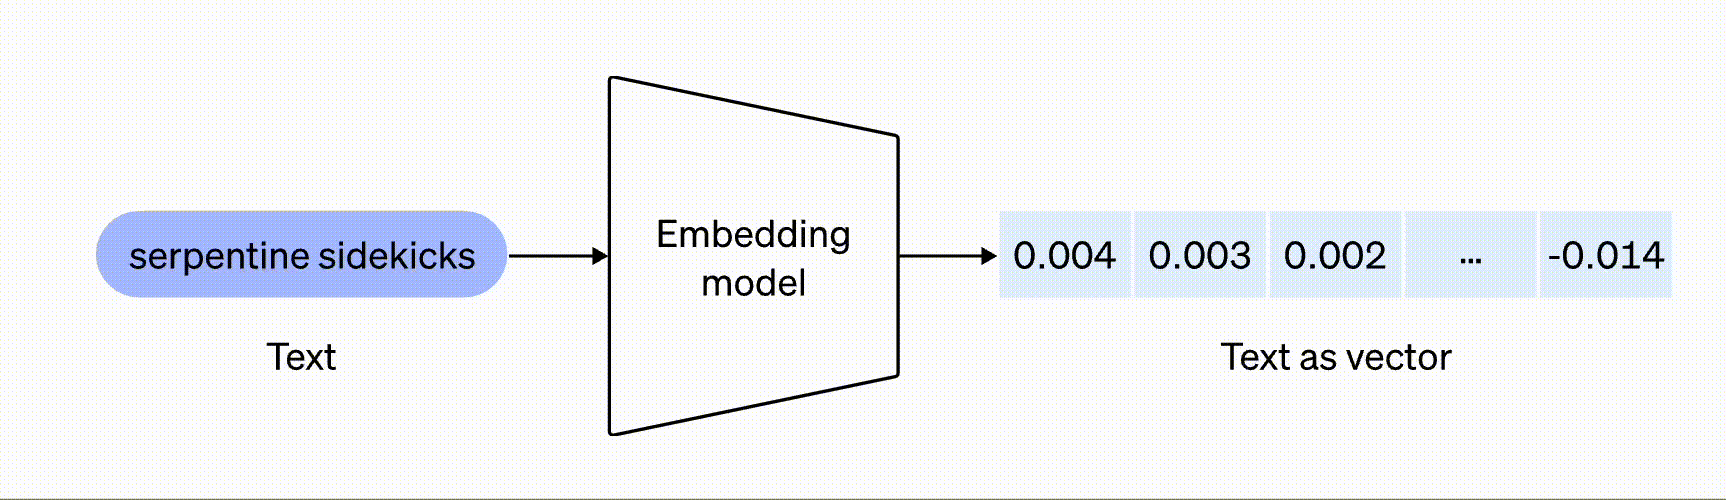

📌 Next, we will do `word embeddings`

📌 Word embeddings capture the semantic relationships between words in a numerical form that machines can understand

In [9]:
!pip install gensim

`Parameter`	- *Description*
__________________________
`cleaned_text`	*Training data*

`min_count`	Frequency threshold

`alpha`	Learning rate

`vector_size`	Embedding dimensions

`window`	Context range

`epochs`	Training iterations

`sg`	Algorithm choice *(`in this case sg=0, meaning it is CBOW model`)*

###What is the difference between CBOW (Continuous Bag of Words) and Skip-Gram?





📌 CBOW: Predicts a target word from surrounding context words.

📌 Skip-Gram: Predicts surrounding context words from a target word.

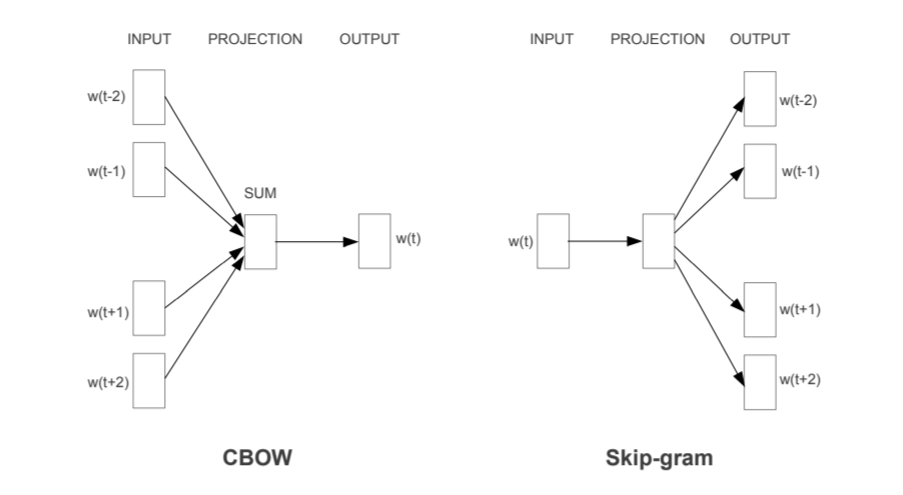

In [15]:
from gensim.models import Word2Vec
word2vec = Word2Vec([cleaned_text], min_count=2, alpha=0.025, vector_size=100,
                    window=5, epochs=155,  sg=0)

📌 Note: Word2Vec processes text by considering the context of words within sentences. This requires the input to be structured as a list of sentences (lists of words).

that's why we used `[cleaned_text]` as training data



In [16]:
word2vec.wv['artificial']

array([-0.4556772 , -0.5431922 , -0.07025775,  1.1186389 ,  0.27846646,
       -0.22260718, -0.10706318,  0.6428954 , -0.90519804, -0.0447007 ,
       -0.3164854 ,  0.08528341, -0.2786668 ,  0.01229961, -0.37241444,
       -0.5636296 ,  0.5458423 , -0.6071977 , -1.1267036 ,  0.00374964,
       -0.26217264,  0.19872272, -0.52376074,  0.4886644 , -0.24500842,
        0.04848381,  0.32840064,  0.14964177, -0.899631  ,  0.22307196,
        0.10715009,  0.08815326,  0.33181393, -0.23605359,  0.19890435,
        0.55221033,  0.1623874 , -0.10743698, -0.4228774 , -0.85076165,
        0.5736962 , -0.18353748, -0.31859332,  0.10754849, -0.21381524,
       -0.29269734, -0.6831042 ,  0.5585191 ,  0.6086904 ,  0.21396288,
        0.01942793, -0.29145786,  0.48422596, -0.35718018, -0.4785258 ,
        0.8478083 , -1.035573  , -0.45967326, -0.40807554,  0.33875394,
        0.13659655, -0.14930087,  0.2513504 , -0.50866294, -1.1052189 ,
        0.02588382,  0.5256748 ,  0.21483271, -0.9735703 ,  0.21

📌 most similar 3 words to word 'artitficial'

In [17]:
word2vec.wv.most_similar(positive = ['artificial'] , topn = 3)

[('intelligence', 0.9407402276992798),
 ('john', 0.9229885935783386),
 ('mccarthy', 0.9167627096176147)]

📌 Note: The model is trained using CBOW and used here for word similarity, but it can also be used for tasks like predicting a missing word or finding related words.


# Using Brown Dataset

In [18]:
import gensim
nltk.download('brown')

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.


True

In [19]:
# Train a Word2Vec model on the first 10,000 sentences from the Brown corpus using default CBOW architecture
from nltk.corpus import brown

train_set = brown.sents()[:10000]
model = gensim.models.Word2Vec(train_set , epochs = 50)

In [20]:
model.wv['University']

array([ 0.0879339 ,  1.5978845 , -0.90558356,  1.1190586 , -0.24620791,
       -0.28250813, -0.97626454, -1.2331179 , -2.0533292 ,  0.78649765,
       -0.9671479 ,  0.12487299,  0.30921403,  0.6693343 , -1.6136194 ,
        0.8444991 ,  0.44490644,  1.5187044 , -1.8740009 , -2.1600907 ,
        0.8942349 , -0.97428787,  1.6545213 , -1.0302807 , -0.86364007,
       -0.42551646, -1.8950925 ,  0.6801493 , -0.32769918,  0.29305157,
        1.545572  , -1.0921311 ,  2.110744  , -0.672797  ,  0.19195615,
        0.3280099 , -2.1254573 , -0.8400409 , -0.36413842, -1.9552234 ,
        1.0209755 , -0.20051603,  0.87591445, -0.5561549 , -0.14116293,
       -0.9757265 , -1.6580745 , -1.0197221 , -0.7722623 ,  0.9821056 ,
       -0.21600693, -0.04421752, -1.7341335 ,  1.0556102 ,  0.13177729,
        0.0864613 , -0.09595349, -1.8772771 , -1.1083795 , -0.22003572,
        0.19458553, -0.1062751 , -0.5041991 ,  0.7680546 , -0.9563788 ,
        0.82486844, -0.6671084 ,  0.80647296, -0.13691016, -1.30

In [21]:
model.wv.most_similar(positive = ['University'] , topn = 3)

[('College', 0.7301860451698303),
 ('School', 0.6420180201530457),
 ('Methodist', 0.6157665252685547)]

📌 similarity between two words

📌 similarity is calculated using cosine similarity

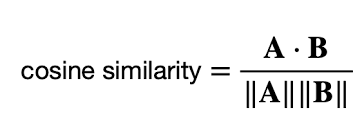

📌 A . B is the `dot product` of the two vectors

📌 ‖A‖ and ‖B‖ are the `magnitudes` (lengths) of the vectors

In [22]:
model.wv.similarity("boy" , "man")

0.54255724

# Using word2vec Pre-trained model

In [23]:
import gensim.downloader
glove_vectors = gensim.downloader.load('glove-twitter-25')

[==================================================] 100.0% 104.8/104.8MB downloaded


In [24]:
# Use the downloaded vectors as usual:
glove_vectors.most_similar('twitter')

[('facebook', 0.948005199432373),
 ('tweet', 0.9403423070907593),
 ('fb', 0.9342358708381653),
 ('instagram', 0.9104824066162109),
 ('chat', 0.8964964747428894),
 ('hashtag', 0.8885937333106995),
 ('tweets', 0.8878158330917358),
 ('tl', 0.8778461217880249),
 ('link', 0.8778210878372192),
 ('internet', 0.8753897547721863)]

In [25]:
glove_vectors.most_similar(positive = ['woman' , 'king'] , negative = ['man'])

[('meets', 0.8841924071311951),
 ('prince', 0.832163393497467),
 ('queen', 0.8257461190223694),
 ('’s', 0.8174097537994385),
 ('crow', 0.813499391078949),
 ('hunter', 0.8131037950515747),
 ('father', 0.8115834593772888),
 ('soldier', 0.81113600730896),
 ('mercy', 0.8082392811775208),
 ('hero', 0.8082264065742493)]

In [27]:
''' Practice '''

import requests
!pip install bs4
import bs4 as bs
import re
import nltk
nltk.download('punkt')
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize
import lxml

# Use requests to get the page content with headers to mimic a browser
url = 'https://en.wikipedia.org/wiki/Artificial_intelligence'
headers = {'User-Agent': 'Mozilla/5.0'} # Mimic a browser
response = requests.get(url, headers=headers)
response.raise_for_status() # Raise an exception for bad status codes

article = response.text

parsed_article = bs.BeautifulSoup(article,'lxml')

paragraphs = parsed_article.find_all('p')

article_text = ""

for p in paragraphs:
    article_text += p.text

print(article_text)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



Artificial intelligence (AI) is the capability of computational systems to perform tasks typically associated with human intelligence, such as learning, reasoning, problem-solving, perception, and decision-making. It is a field of research in computer science that develops and studies methods and software that enable machines to perceive their environment and use learning and intelligence to take actions that maximize their chances of achieving defined goals.[1]
High-profile applications of AI include advanced web search engines (e.g., Google Search); recommendation systems (used by YouTube, Amazon, and Netflix); virtual assistants (e.g., Google Assistant, Siri, and Alexa); autonomous vehicles (e.g., Waymo); generative and creative tools (e.g., language models and AI art); and superhuman play and analysis in strategy games (e.g., chess and Go). However, many AI applications are not perceived as AI: "A lot of cutting edge AI has filtered into general applications, often without being c